## Business Problem Statement

Customer churn — when customers leave a company — is a critical issue for telecom businesses. Retaining an existing customer is significantly more cost-effective than acquiring a new one. Telco companies are under constant pressure to improve customer retention strategies, but without data-driven insights, identifying at-risk customers is inefficient and reactive.

This project focuses on developing a predictive machine learning model to identify customers who are likely to churn, using historical service usage, customer demographics, and contract-related data. The insights from this model can help the company proactively target high-risk customers with personalized offers or interventions, potentially reducing churn and increasing long-term customer value.

**Business Impact**:
- Improve retention campaigns through targeted intervention
- Reduce revenue loss from churn
- Optimize marketing and customer service efforts

**Data Source**:
- [Telco Customer Churn – Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**ML Task**:
- **Binary Classification** (predict whether a customer will churn or not)


### loading libraries and dataset

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [33]:
df = pd.read_csv("https://raw.githubusercontent.com/wckd6174/data_learning/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data exploration

In [34]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [35]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


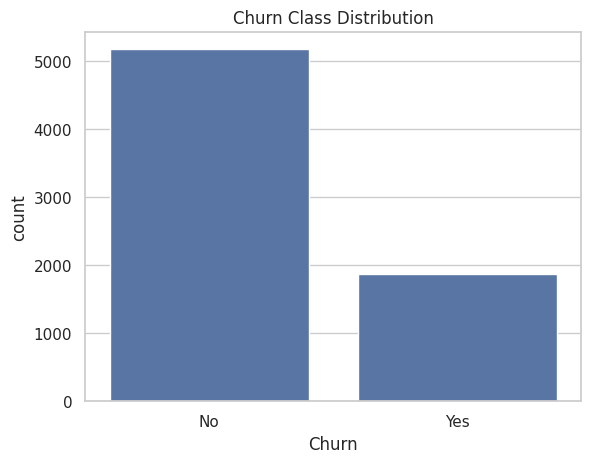

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [36]:
sns.countplot(data=df, x='Churn')
plt.title("Churn Class Distribution")
plt.show()

print(df['Churn'].value_counts(normalize=True))

In [37]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [38]:
df = df.dropna()
df = df.drop(columns=['customerID'])

### Data preprocessing

In [39]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop('Churn', axis=1)
y = df['Churn']

In [40]:
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [41]:
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

### Splitting data into train and test

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (5625, 30) | Test shape: (1407, 30)


### Training baseline model

In [43]:
def build_model(input_dim, dropout_rate=0.3, layers=[64, 32]):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [44]:
input_dim = X_train.shape[1]
model = build_model(input_dim)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6078 - loss: 0.7464 - val_accuracy: 0.7902 - val_loss: 0.4865
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7531 - loss: 0.5201 - val_accuracy: 0.8000 - val_loss: 0.4387
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7653 - loss: 0.4947 - val_accuracy: 0.8018 - val_loss: 0.4254
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7841 - loss: 0.4562 - val_accuracy: 0.7982 - val_loss: 0.4212
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7827 - loss: 0.4738 - val_accuracy: 0.8018 - val_loss: 0.4168
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7827 - loss: 0.4547 - val_accuracy: 0.8000 - val_loss: 0.4144
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7877 - loss: 0.4551 - val_accuracy: 0.8009 - val_loss: 0.4159
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8044 - loss: 0.4237 - val_accuracy: 0.7964 - val_

### Plotting training curves

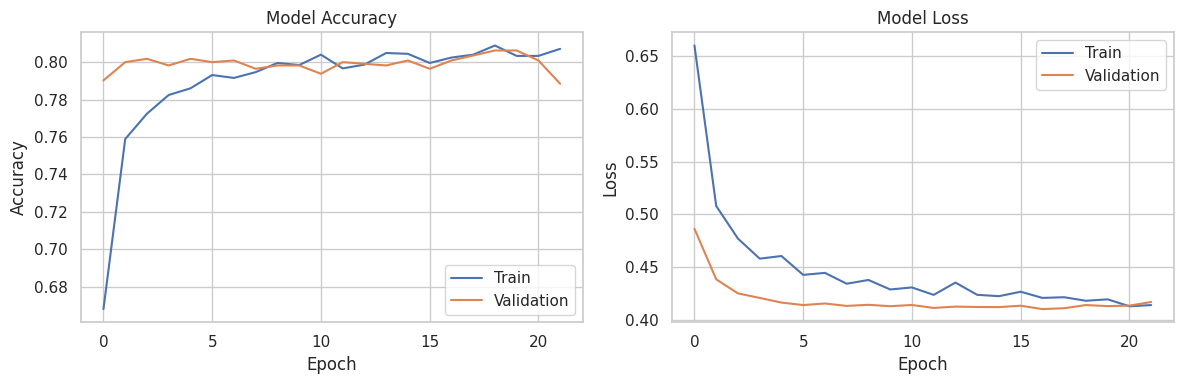

In [45]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Creating and running ten diffrent model variations

In [46]:
from tensorflow.keras.optimizers import Adam, RMSprop

results = []

def run_experiment(config_id, layers, dropout, batch_size, optimizer='adam', epochs=30):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(1, activation='sigmoid'))

    opt = Adam() if optimizer == 'adam' else RMSprop()

    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    val_acc = max(history.history['val_accuracy'])
    results.append({
        'ID': config_id,
        'Layers': '-'.join(map(str, layers)),
        'Dropout': dropout,
        'Batch Size': batch_size,
        'Optimizer': optimizer,
        'Epochs': len(history.history['val_accuracy']),
        'Val Accuracy': round(val_acc, 4)
    })

    print(f"Config {config_id} complete → Val Accuracy: {val_acc:.4f}")

In [47]:
run_experiment(config_id=1, layers=[64, 32], dropout=0.3, batch_size=32, optimizer='adam')
run_experiment(config_id=2, layers=[128, 64], dropout=0.2, batch_size=64, optimizer='adam')
run_experiment(config_id=3, layers=[32], dropout=0.3, batch_size=16, optimizer='adam')
run_experiment(config_id=4, layers=[64, 64, 32], dropout=0.4, batch_size=32, optimizer='rmsprop')
run_experiment(config_id=5, layers=[128, 64, 32], dropout=0.3, batch_size=64, optimizer='rmsprop')
run_experiment(config_id=6, layers=[256, 128], dropout=0.2, batch_size=32, optimizer='adam')
run_experiment(config_id=7, layers=[32, 16], dropout=0.5, batch_size=16, optimizer='adam')
run_experiment(config_id=8, layers=[64, 32], dropout=0.1, batch_size=64, optimizer='rmsprop')
run_experiment(config_id=9, layers=[128, 64, 64], dropout=0.2, batch_size=32, optimizer='adam')
run_experiment(config_id=10, layers=[64], dropout=0.25, batch_size=32, optimizer='adam')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Config 1 complete → Val Accuracy: 0.8089


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Config 2 complete → Val Accuracy: 0.8000
Config 3 complete → Val Accuracy: 0.8098


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Config 8 complete → Val Accuracy: 0.8071


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Config 9 complete → Val Accuracy: 0.8044


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Config 10 complete → Val Accuracy: 0.8062


### Viewing the results as a table

In [48]:
experiment_df = pd.DataFrame(results)

experiment_df.sort_values(by='Val Accuracy', ascending=False).reset_index(drop=True)

,ID,Layers,Dropout,Batch Size,Optimizer,Epochs,Val Accuracy
0,7,32-16,0.50,16,adam,18,0.8107
1,3,32,0.30,16,adam,19,0.8098
2,1,64-32,0.30,32,adam,21,0.8089
3,4,64-64-32,0.40,32,rmsprop,14,0.8080
4,8,64-32,0.10,64,rmsprop,10,0.8071
5,5,128-64-32,0.30,64,rmsprop,18,0.8071
6,10,64,0.25,32,adam,10,0.8062
7,9,128-64-64,0.20,32,adam,13,0.8044
8,2,128-64,0.20,64,adam,11,0.8000
9,6,256-128,0.20,32,adam,9,0.7973


we can see that the best model is ID 7 with accuracy of 0.8107

### Rebuilding the model with the configuratons of the best model

In [49]:
best_model = build_model(input_dim=input_dim, dropout_rate=0.5, layers=[32, 16])

best_history = best_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5742 - loss: 0.7513 - val_accuracy: 0.7742 - val_loss: 0.4851
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7092 - loss: 0.5642 - val_accuracy: 0.7849 - val_loss: 0.4412
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7447 - loss: 0.5159 - val_accuracy: 0.7947 - val_loss: 0.4248
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7670 - loss: 0.4808 - val_accuracy: 0.8000 - val_loss: 0.4208
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7672 - loss: 0.4767 - val_accuracy: 0.8009 - val_loss: 0.4172
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7703 - loss: 0.4629 - val_accuracy: 0.7991 - val_loss: 0.4113
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7880 - loss: 0.4599 - val_accuracy: 0.8009 - val_loss: 0.4110
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7676 - loss: 0.4616 - val_accuracy: 0.

### Predicting on test set

In [50]:
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### Classification report

In [51]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



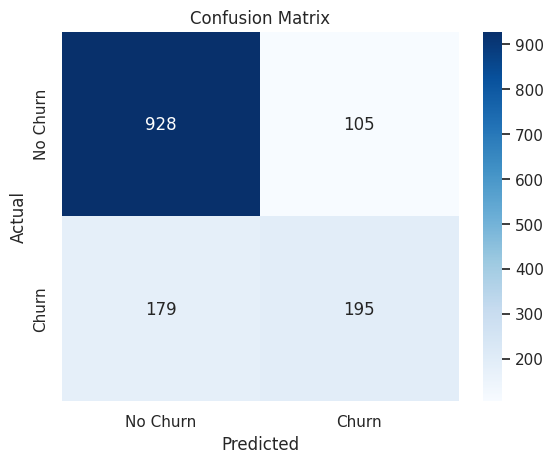

In [52]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score: 0.8337


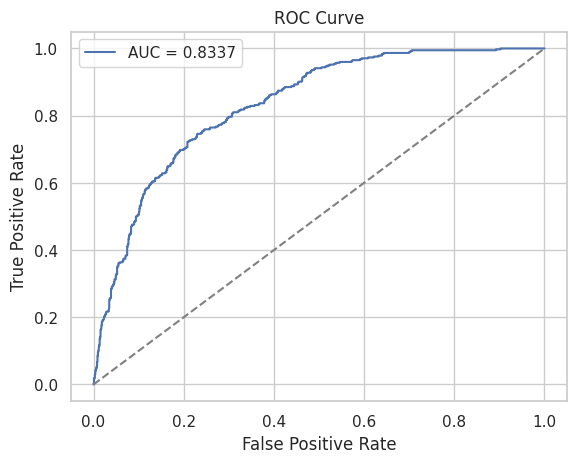

In [53]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_score = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f'AUC = {roc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


## Final Discussion and Recommendations

###  Strengths of the Model
- The deep learning model achieved an overall test accuracy of 80%, with strong performance on the majority class (non-churn).
- The use of early stopping and dropout (0.5) helped control overfitting, making the model generalize well to unseen data.
- The model architecture is lightweight and scalable, and can be retrained regularly as new data becomes available.

###  Limitations
- There is a noticeable performance gap between classes: precision/recall for the churn class (1) are lower than for non-churn.
- Recall for churn is 0.52, which means about half of the actual churners are being missed ,this could be critical for business impact.
- Neural networks provide limited model explainability compared to tree-based models like Random Forest or XGBoost.

###  Business Implications
- Despite limitations, the model provides a useful early-warning system to flag potential churners.
- By using this model, the telecom company could launch targeted retention campaigns, focusing on customers with high predicted churn probability.
- Even a small uplift in retention can lead to significant revenue preservation.

###  Recommendations
- Further boost recall for churn (class 1) using techniques like class weighting, SMOTE, or threshold tuning.
- Integrate explainability tools like SHAP or permutation importance to understand the top drivers of churn.
- For deployment, wrap the trained model into an API using Flask or FastAPI, and set up a regular re-training schedule.

###  Deployment Readiness
- The model is ready for deployment as a churn scoring engine.
- A monitoring system should track drift and model performance over time to trigger retraining when needed.
